In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import sympy as sp
from scipy.optimize import root
from sympy import symbols, diff
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
from matplotlib.colors import ListedColormap, Normalize
import matplotlib as mpl
from matplotlib.lines import Line2D

/var/tmp/pbs.2042351.pbs-7/ipykernel_1886370/3958279397.py:40: RuntimeWarning: divide by zero encountered in divide
  pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
/var/tmp/pbs.2042351.pbs-7/ipykernel_1886370/3958279397.py:40: RuntimeWarning: invalid value encountered in divide
  pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
/var/tmp/pbs.2042351.pbs-7/ipykernel_1886370/3958279397.py:40: RuntimeWarning: invalid value encountered in cos
  pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)


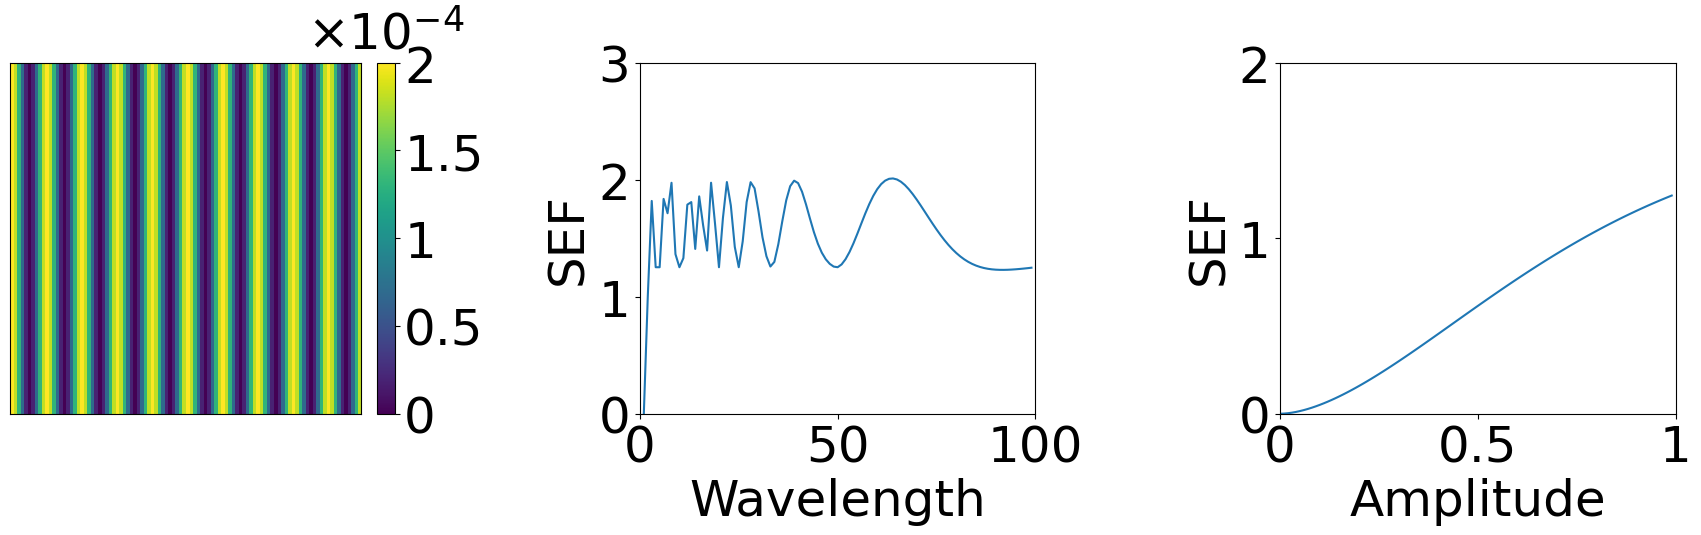

In [27]:
n = 100
wavelength = 10
amplitude = 1

# Create coordinate grid
x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelength)

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 3,
    figsize=(18, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,0.5]}
)

fig.subplots_adjust(wspace=0.05)
# Remove ticks
axs[0].set_xticks([])
axs[0].set_yticks([])

# [0]
pattern_disp = pattern / np.sum(pattern)
img = axs[0].imshow(pattern_disp, vmin=0, vmax=0.0002)

cbar = plt.colorbar(img, ax=axs[0], fraction=0.046, pad=0.04)
cbar.set_ticks([0, 0.00005,0.0001,0.00015,  0.0002])
cbar.set_ticklabels(['0', '0.5', '1', '1.5', '2'])
cbar.ax.set_title(r'$\times 10^{-4}$', fontsize=fon, pad=10)



#[1]
sef_storage = []
for wavelen in range(0,100):
    pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[1].plot(sef_storage)
axs[1].set_xlabel("Wavelength")
axs[1].set_ylabel("SEF")
axs[1].set_xlim(0,100)
axs[1].set_ylim(0,3)

#[1]
sef_storage_2 = []
for amp in range(0,100):
    pattern = 1 + amp*0.01*np.cos(2 * np.pi * X / wavelength)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage_2.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[2].plot(sef_storage_2)
axs[2].set_xlabel("Amplitude")
axs[2].set_ylabel("SEF")
axs[2].set_xlim(0,100)
axs[2].set_xticks([0,50,100],[0,0.5,1])
axs[2].set_ylim(0,2)
    




plt.tight_layout()
plt.savefig('supp_fig_cos')
plt.show()

range(10, 50)

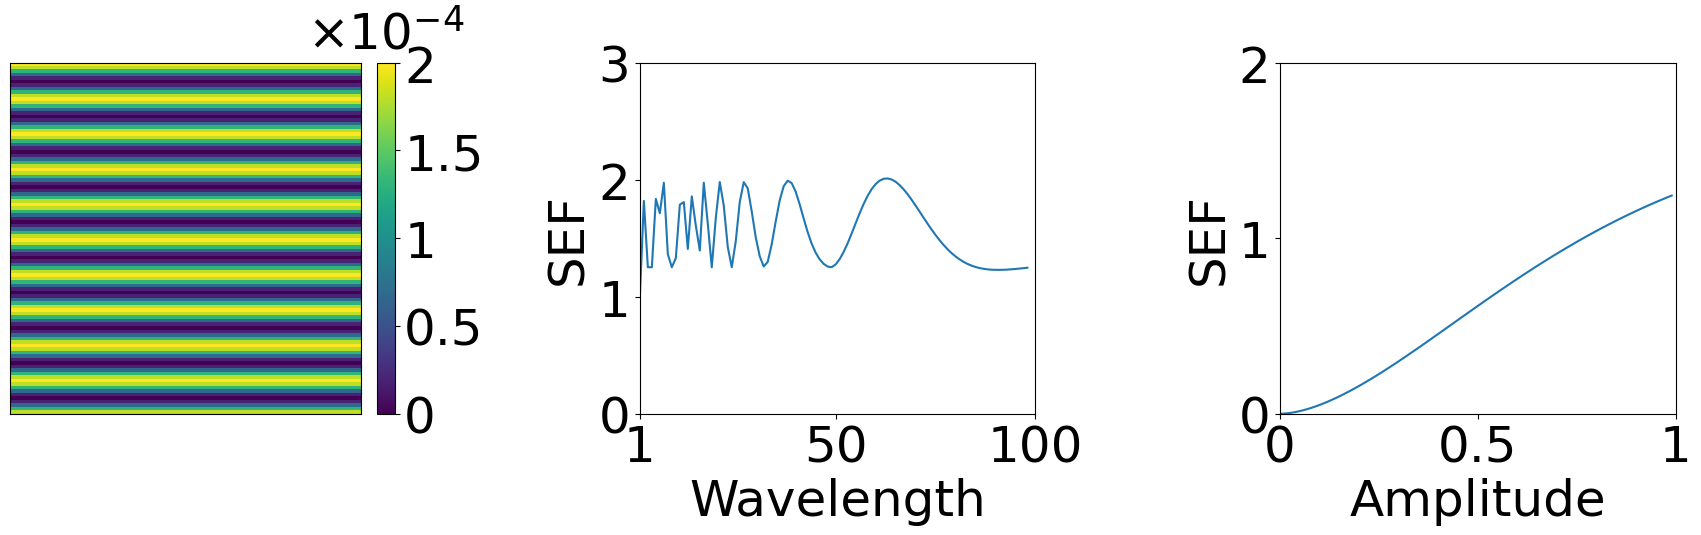

In [73]:
n = 100
wavelength = 10
amplitude = 1

# Create coordinate grid
x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * Y / wavelength)

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 3,
    figsize=(18, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,0.5]}
)

fig.subplots_adjust(wspace=0.05)
# Remove ticks
axs[0].set_xticks([])
axs[0].set_yticks([])

# [0]
pattern_disp = pattern / np.sum(pattern)
img = axs[0].imshow(pattern_disp, vmin=0, vmax=0.0002)

cbar = plt.colorbar(img, ax=axs[0], fraction=0.046, pad=0.04)
cbar.set_ticks([0, 0.00005,0.0001,0.00015,  0.0002])
cbar.set_ticklabels(['0', '0.5', '1', '1.5', '2'])
cbar.ax.set_title(r'$\times 10^{-4}$', fontsize=fon, pad=10)



#[1]
sef_storage = []
for wavelen in range(1,100):
    pattern = 1 + amplitude*np.cos(2 * np.pi * Y / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[1].plot(sef_storage)
axs[1].set_xlabel("Wavelength")
axs[1].set_ylabel("SEF")
axs[1].set_xlim(1,100)

axs[1].set_xticks([1,50,100])
axs[1].set_ylim(0,3)

#[1]
sef_storage_2 = []
for amp in range(0,100):
    pattern = 1 + amp*0.01*np.cos(2 * np.pi * Y / wavelength)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage_2.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[2].plot(sef_storage_2)
axs[2].set_xlabel("Amplitude")
axs[2].set_ylabel("SEF")
axs[2].set_xlim(0,100)

axs[2].set_xticks([0,50,100],[0,0.5,1])
axs[2].set_ylim(0,2)
    




plt.tight_layout()

plt.savefig('supp_fig_orient')
plt.show()

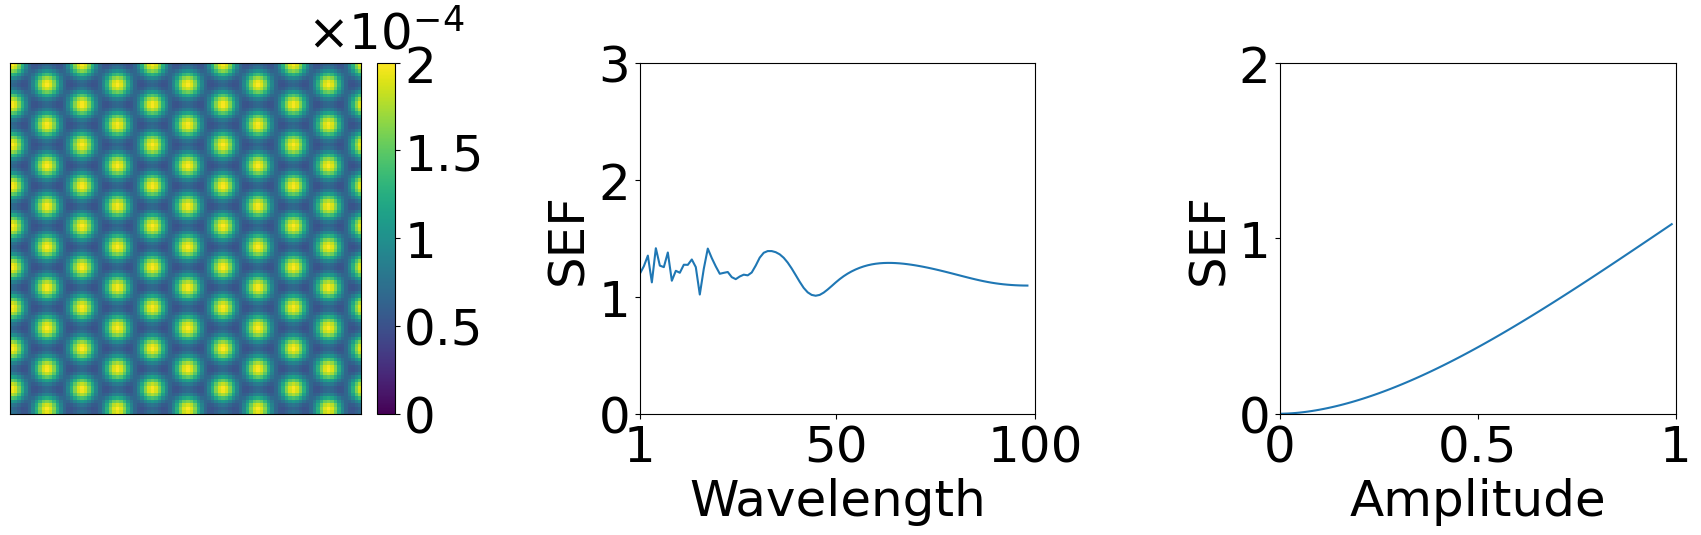

In [77]:
n = 100
wavelength = 10
amplitude = 1

x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

k = 2 * np.pi / wavelength

# Three wavevectors 120° apart
pattern = 1 + (
    (amplitude/3)*np.cos(k * X) +
    (amplitude/3)*np.cos(k * (-0.5*X + np.sqrt(3)/2 * Y)) +
    (amplitude/3)*np.cos(k * (-0.5*X - np.sqrt(3)/2 * Y))
)


fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 3,
    figsize=(18, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,0.5]}
)

fig.subplots_adjust(wspace=0.05)
# Remove ticks
axs[0].set_xticks([])
axs[0].set_yticks([])

# [0]
pattern_disp = pattern / np.sum(pattern)
img = axs[0].imshow(pattern_disp, vmin=0, vmax=0.0002)

cbar = plt.colorbar(img, ax=axs[0], fraction=0.046, pad=0.04)
cbar.set_ticks([0, 0.00005,0.0001,0.00015,  0.0002])
cbar.set_ticklabels(['0', '0.5', '1', '1.5', '2'])
cbar.ax.set_title(r'$\times 10^{-4}$', fontsize=fon, pad=10)



#[1]
sef_storage = []
for wavelen in range(1,100):
    k = 2 * np.pi / wavelen
    pattern = 1 + (
    (amplitude/3)*np.cos(k * X) +
    (amplitude/3)*np.cos(k * (-0.5*X + np.sqrt(3)/2 * Y)) +
    (amplitude/3)*np.cos(k * (-0.5*X - np.sqrt(3)/2 * Y)))
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[1].plot(sef_storage)
axs[1].set_xlabel("Wavelength")
axs[1].set_ylabel("SEF")
axs[1].set_xlim(1,100)
axs[1].set_xticks([1,50,100],[1,50,100])
axs[1].set_ylim(0,3)

#[1]
sef_storage_2 = []
for amp in range(0,100):
    pattern = 1 + (
    (amp*0.01/3)*np.cos(k * X) +
    (amp*0.01/3)*np.cos(k * (-0.5*X + np.sqrt(3)/2 * Y)) +
    (amp*0.01/3)*np.cos(k * (-0.5*X - np.sqrt(3)/2 * Y)))
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage_2.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[2].plot(sef_storage_2)
axs[2].set_xlabel("Amplitude")
axs[2].set_ylabel("SEF")
axs[2].set_xlim(0,100)
axs[2].set_xticks([0,50,100],[0,0.5,1])
axs[2].set_ylim(0,2)
    


plt.tight_layout()
plt.savefig('supp_fig_spots_half')
plt.show()

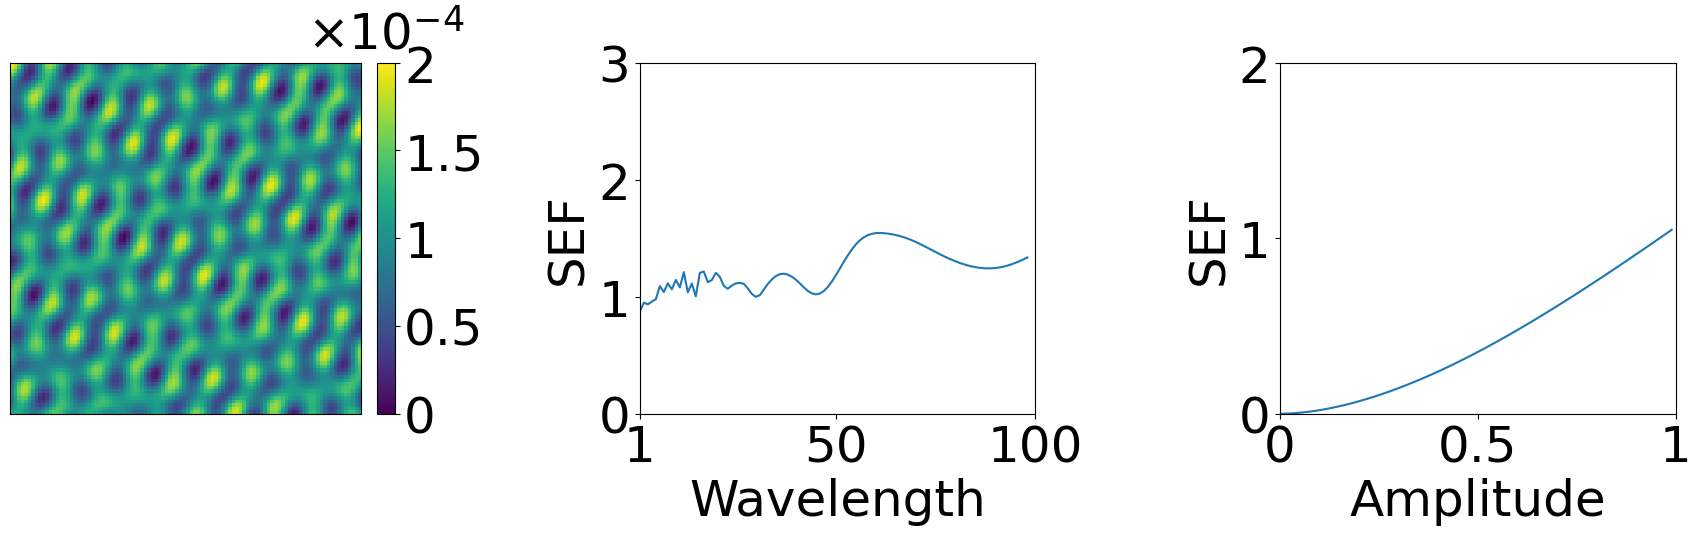

In [66]:

n = 100
wavelength = 10
k = 2*np.pi / wavelength
N = 5                      # number of modes
amplitude = 1

x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = np.ones((n, n))
np.random.seed(0)
angles = np.random.uniform(0, 2*np.pi, N)

for theta in angles:
    kx = k * np.cos(theta)
    ky = k * np.sin(theta)
    alpha = amplitude / N
    pattern += alpha * np.cos(kx*X + ky*Y)

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 3,
    figsize=(18, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,0.5]}
)

fig.subplots_adjust(wspace=0.05)
# Remove ticks
axs[0].set_xticks([])
axs[0].set_yticks([])

# [0]
pattern_disp = pattern / np.sum(pattern)
img = axs[0].imshow(pattern_disp, vmin=0, vmax=0.0002)

cbar = plt.colorbar(img, ax=axs[0], fraction=0.046, pad=0.04)
cbar.set_ticks([0, 0.00005,0.0001,0.00015,  0.0002])
cbar.set_ticklabels(['0', '0.5', '1', '1.5', '2'])
cbar.ax.set_title(r'$\times 10^{-4}$', fontsize=fon, pad=10)



#[1]
sef_storage = []
for wavelen in range(1,100):
    pattern = np.ones((n, n))
    k = 2*np.pi / wavelen
    np.random.seed(0)
    angles = np.random.uniform(0, 2*np.pi, N)
    
    for theta in angles:
        kx = k * np.cos(theta)
        ky = k * np.sin(theta)
        alpha = amplitude / N
        pattern += alpha * np.cos(kx*X + ky*Y)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[1].plot(sef_storage)
axs[1].set_xlabel("Wavelength")
axs[1].set_ylabel("SEF")
axs[1].set_xlim(1,100)
axs[1].set_xticks([1,50,100],[1,50,100])
axs[1].set_ylim(0,3)

#[1]
sef_storage_2 = []
for amp in range(0,100):
    pattern = np.ones((n, n))
    k = 2*np.pi / wavelength
    np.random.seed(0)
    angles = np.random.uniform(0, 2*np.pi, N)
    
    for theta in angles:
        kx = k * np.cos(theta)
        ky = k * np.sin(theta)
        alpha = amp*0.01 / N
        pattern += alpha * np.cos(kx*X + ky*Y)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage_2.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[2].plot(sef_storage_2)
axs[2].set_xlabel("Amplitude")
axs[2].set_ylabel("SEF")
axs[2].set_xlim(0,100)
axs[2].set_xticks([0,50,100],[0,0.5,1])
axs[2].set_ylim(0,2)
    



plt.tight_layout()
plt.savefig('supp_fig_labyrinth')
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import sympy as sp
from scipy.optimize import root
from sympy import symbols, diff
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
from matplotlib.colors import ListedColormap, Normalize
import matplotlib as mpl
#Steady state solver
def solve_ss(k1, k2, params):

    # Define symbolic variables
    a, b = sp.symbols('a b', real=True)
    b_a, v_a, k_a, k_ba, mu_a = sp.symbols('b_a v_a k_a k_ba mu_a', real=True)
    b_b, v_b, k_ab, mu_b = sp.symbols('b_b v_b k_ab mu_b', real=True)

    # Define steady-state equations
    r_d_a = b_a + v_a * 1 / (1 + (k_a / a) ** 2) * 1 / (1 + (b / k_ba) ** 2) - mu_a * a
    r_d_b = b_b + v_b * 1 / (1 + (k_ab / a) ** 2) - mu_b * b
    # Assign values to variables
    mod_pars = params[2:]
    values = {
        b_a: mod_pars[3], v_a: mod_pars[0], k_ba: mod_pars[2], mu_a: mod_pars[5],
        b_b: mod_pars[4], v_b: mod_pars[1], mu_b: mod_pars[6],k_a: k1,k_ab: k2,
    }

    # Convert symbolic expressions into numerical functions
    r_d_a_num = sp.lambdify((a, b), r_d_a.subs(values), 'numpy')
    r_d_b_num = sp.lambdify((a, b), r_d_b.subs(values), 'numpy')

    # Define system of equations
    def equations(vars):
        a, b = vars
        return np.array([r_d_a_num(a, b), r_d_b_num(a, b)])

    # Try multiple solvers for robustness
    initial_guesses = [[4, 2], [1, 1], [10, 5], [0.1, 0.1]]
    solvers = ['hybr', 'lm', 'broyden1', 'df-sane']
    
    for guess in initial_guesses:
        for method in solvers:
            result = root(equations, guess, method=method)
            if result.success:
                return result.x  # Return solution if successful

    raise RuntimeError("No solution found with tested solvers and initial guesses.")

#Steady state solver (informed, using precomputed values for accuracy)
def solve_ss2(k1, k2, params,given_sol):
    # Define symbolic variables
    a, b = sp.symbols('a b', real=True)
    b_a, v_a, k_a, k_ba, mu_a = sp.symbols('b_a v_a k_a k_ba mu_a', real=True)
    b_b, v_b, k_ab, mu_b = sp.symbols('b_b v_b k_ab mu_b', real=True)

    # Define steady-state equations
    r_d_a = b_a + v_a * 1 / (1 + (k_a / a) ** 2) * 1 / (1 + (b / k_ba) ** 2) - mu_a * a
    r_d_b = b_b + v_b * 1 / (1 + (k_ab / a) ** 2) - mu_b * b

    # Assign values to variables
    mod_pars = params[2:]
    values = {
        b_a: mod_pars[3],
        v_a: mod_pars[0],
        k_ba: mod_pars[2],
        mu_a: mod_pars[5],
        b_b: mod_pars[4],
        v_b: mod_pars[1],
        mu_b: mod_pars[6],
        k_a: k1,
        k_ab: k2,
    }

    # Convert symbolic expressions into numerical functions
    r_d_a_num = r_d_a.subs(values)
    r_d_b_num = r_d_b.subs(values)

    # Define system of equations
    def equations(vars):
        a_val, b_val = vars
        return np.array([r_d_a_func(a_val, b_val), r_d_b_func(a_val, b_val)])

    # steady_state = given_sol
    # u0 = sp.nsolve([r_d_a_num, r_d_b_num], [a, b], steady_state, prec = 100)
    # return u0

    # Try multiple initial guesses
    initial_guesses = [given_sol, [0.1, 0.1], [1, 1], [4, 2], [10, 5]]

    for guess in initial_guesses:
        try:
            sol = sp.nsolve([r_d_a_num, r_d_b_num], [a, b], guess, prec=20)
            return sol
        except Exception:
            continue

    raise RuntimeError("No solution found with any initial guess in solve_ss2")
    
def Net8_pat(a, b, mod_pars, k1, k2):  # Reaction terms
    v_a, v_b, k_ba, b_a, b_b, mu_a, mu_b = mod_pars
    k_a, k_ab = k1, k2

    # Clamp a and b to avoid division by zero or overflow
    a_safe = np.clip(a, 1e-8, None)
    b_safe = np.clip(b, 1e-8, None)

    f1 = b_a + v_a * (1 / (1 + (k_a / a_safe) ** 2)) * (1 / (1 + (b_safe / k_ba) ** 2)) - mu_a * a
    f2 = b_b + v_b * (1 / (1 + (k_ab / a_safe) ** 2)) - mu_b * b

    return f1, f2



def Net8_cycle(k1, k2, radius, speed_r, speed_theta, cent_cyc, tangential_noise, radial_noise):
    # Center coordinates
    k1star, k2star = cent_cyc
    x = k1 - k1star
    y = k2 - k2star
    r = np.sqrt(x**2 + y**2)

    # Core deterministic dynamics
    lin1 = x * (speed_r * (radius - r))
    lin2 = y * (speed_r * (radius - r))
    an1 = y * speed_theta
    an2 = x * speed_theta

    # Unit radial and tangential vectors
    if r == 0:
        unit_r = [1.0, 0.0]
        unit_t = [0.0, 1.0]
    else:
        unit_r = [x / r, y / r]
        unit_t = [-y / r, x / r]

    # Add radial noise (in/out movement)
    rad_noise = np.random.normal(0, radial_noise)
    rad_x = rad_noise * unit_r[0]
    rad_y = rad_noise * unit_r[1]

    # Add tangential noise (spin variation)
    tang_noise = np.random.normal(0, tangential_noise)
    tang_x = tang_noise * unit_t[0]
    tang_y = tang_noise * unit_t[1]

    # Final dynamics
    f1 = lin1 - an1 + rad_x + tang_x
    f2 = lin2 + an2 + rad_y + tang_y

    return f1, f2


def laplacian_neumann(u, dx):
    # Pad with edge values (ghost cells): enforces ∂u/∂n = 0 at the boundary
    up = np.pad(u, pad_width=1, mode='edge')
    return (
        up[2:, 1:-1] + up[:-2, 1:-1] + up[1:-1, 2:] + up[1:-1, :-2]
        - 4.0 * up[1:-1, 1:-1]
    ) / (dx**2)
    
def simulate_LC_TP(
    y0, t0, t_max, dt, c, dx, bound_cond, modelfuns, r,
    noise_amp, v_r, v_theta, cent_cyc, k1_0, k2_0,tangential_noise, radial_noise
):

    def laplacian(u):
        return laplacian_neumann(u, dx)

    # Setup initial conditions
    dim = int(np.sqrt(len(y0[:-2]) // 2))  # infer grid size
    params = c
    mod_pars = params[2:]
    ss1 = solve_ss(k1_0,k2_0,params)[0]
    ss2 = solve_ss(k1_0,k2_0,params)[1]
    ss_1 = float(solve_ss2(k1_0,k2_0,params,[ss1,ss2])[0])
    ss_2 = float(solve_ss2(k1_0,k2_0,params,[ss1,ss2])[1])
    a = np.reshape(np.zeros(dim*dim) + ss_1,(dim,dim)) # Initialise Uniform steady state concentration of a and b
    b = np.reshape(np.zeros(dim*dim) + ss_2,(dim,dim)) 
    k1 = k1_0 # Initial k1 k2.
    k2 = k2_0
    t = t0
    results = []  # List to store time, concentrations, and rate constants
    n = 0
    while t < t_max:

        # Compute reaction terms for current concentrations
        f1_now, f2_now = modelfuns[0](a, b, mod_pars, k1, k2)
        g1_now, g2_now = modelfuns[1](k1, k2, r, v_r, v_theta, cent_cyc,tangential_noise, radial_noise)

        Da = params[0]
        Db = params[1]

        lap_a = laplacian(a)
        lap_b = laplacian(b)

        dydt_a = Da * lap_a + f1_now 
        dydt_b = Db * lap_b + f2_now 

        #concentration prediction (first step)
        a_pred = a + dt * dydt_a
        b_pred = b + dt * dydt_b

        k1_pred = k1 + dt * g1_now
        k2_pred = k2 + dt * g2_now

        # Get the predicted reaction terms for the predicted concentrations
        f1_pred, f2_pred = modelfuns[0](a_pred, b_pred, mod_pars, k1_pred, k2_pred)
        g1_pred, g2_pred = modelfuns[1](k1_pred, k2_pred, r, v_r, v_theta, cent_cyc,tangential_noise, radial_noise)

        # Second step
        lap_a_pred = laplacian(a_pred)
        lap_b_pred = laplacian(b_pred)

        dydt_a_pred = Da * lap_a_pred + f1_pred
        dydt_b_pred = Db * lap_b_pred + f2_pred

        #Noise terms
        noise_a = a*(noise_amp * np.sqrt(dt) * np.random.randn(*a.shape))
        noise_b = b*(noise_amp * np.sqrt(dt) * np.random.randn(*b.shape))

        # Final update step using both predicted and current steps
        a += 0.5 * dt * (dydt_a + dydt_a_pred) + noise_a
        b += 0.5 * dt * (dydt_b + dydt_b_pred) + noise_b

        # Prevent negative or NaN values
        a = np.nan_to_num(a, nan=0.0, posinf=1e10, neginf=0.0)
        b = np.nan_to_num(b, nan=0.0, posinf=1e10, neginf=0.0)

        a = np.clip(a, 1e-10, None)  # Enforces a minimum of 0
        b = np.clip(b, 1e-10, None)

        
        # Compute the rate of change of k1 and k2 (using the limit cycle dynamics)
        k1 += 0.5 * dt * (g1_now + g1_pred)
        k2 += 0.5 * dt * (g2_now + g2_pred)
        # Store time, concentration, and parameters at each time step
        if int(n%(1/dt)) == 0.0: 
            results.append({
                't': t,   # Current time
                'u': a.copy(),  # Concentration of A (u)
                'v': b.copy(),  # Concentration of B (v)
                'k1': k1,  # Reaction rate constant k1
                'k2': k2   # Reaction rate constant k2
            })
            print("hi")
        n += 1
        t += dt


    return results


In [ ]:
r, v_r, v_theta = 5, 0.01, 0.01 # 8, 0.3, 0.006

bound_cond = "Neumann"
nx = 500
ny = 500

model_eq = [Net8_pat, Net8_cycle] 

params = [
    1,       # D_A: activator diffusion
    25,      # D_B: inhibitor diffusion (moderately faster than D_A)
    3500,     # V_A: 
    3500,    # V_B: 
    0.5,     # k_BA: 
    1,    # b_A: 
    1,    # b_B: 
    6,     # μ_A: 
    8       # μ_B: 
] 
mod_pars = params[2:]
dx = 1/10
factor = 1 
cent_cyc = [13.0163162287472, 38.505358175996605]

y0 = np.zeros(2 * nx * ny + 2)

dt = 0.0001
k1 = 11 # Where you want to start your cycle in x axis
k2 = 34 # Where you want to start your cycle in y axis
result_sim = simulate_LC_TP(
                y0=y0.copy(),
                t0=0,
                t_max=20,
                dt=dt,
                c=params,
                dx=dx,
                bound_cond=bound_cond,
                modelfuns=model_eq,
                r=r,
                noise_amp=0.01,
                v_r=0,
                v_theta=0,
                cent_cyc=cent_cyc,
                k1_0 = k1,
                k2_0 = k2,
                tangential_noise = 0, 
                radial_noise = 0)

hi


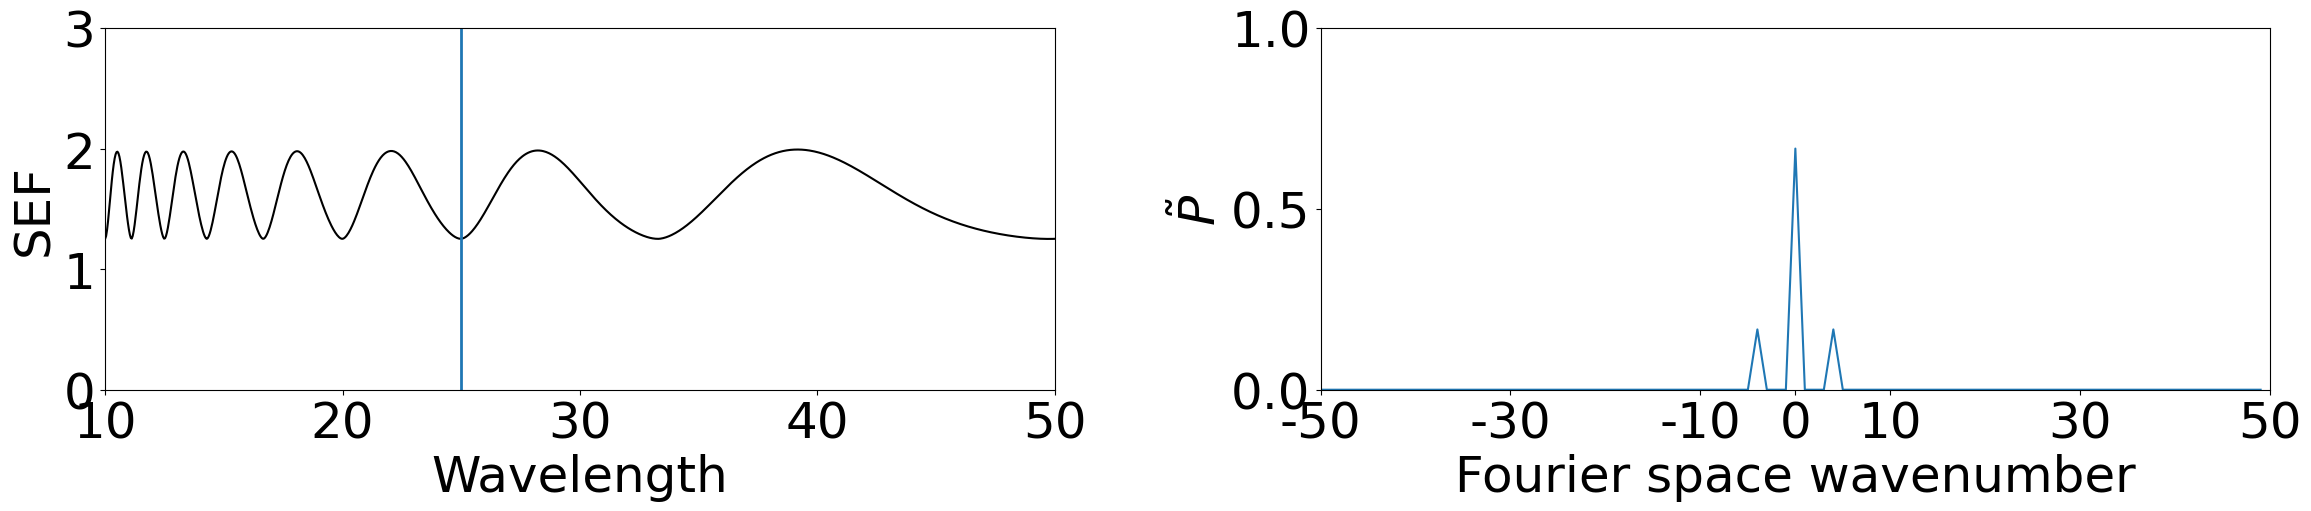

In [59]:
n = 100
wavelength = 25
amplitude = 1

# Create coordinate grid
x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelength)

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 2,
    figsize=(24, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,]}
)

fig.subplots_adjust(wspace=0.05)
# Remove ticks

# [0]
pattern_disp = pattern / np.sum(pattern)
fft_vals = np.fft.fft2(pattern)
fft_shifted = np.fft.fftshift(fft_vals)
power_spectrum = abs(fft_shifted)**2
power_spectrum_norm = power_spectrum/np.sum(power_spectrum)
power_spectrum_norm_disp = power_spectrum_norm


wav = np.linspace(10,50,1000)

sef_storage = []
for wavelen in wav:
    pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[0].plot(wav,sef_storage,"black")
axs[0].set_xlabel("Wavelength")
axs[0].set_ylabel("SEF")
axs[0].set_xlim(10,50)
axs[0].set_ylim(0,3)
axs[0].axvline(25,linewidth = 2)

#[1]

axs[1].plot(power_spectrum_norm_disp[50])
axs[1].set_xlabel("Fourier space wavenumber")
axs[1].set_ylabel(r"$\tilde{P}$")
axs[1].set_xlim(0,100)
axs[1].set_xticks([0,20,40,50,60,80,100],[-50,-30,-10,0,10,30,50])
axs[1].set_ylim(0,1)
    

plt.tight_layout()
plt.savefig('supp_fig_oscsef_1')
plt.show()

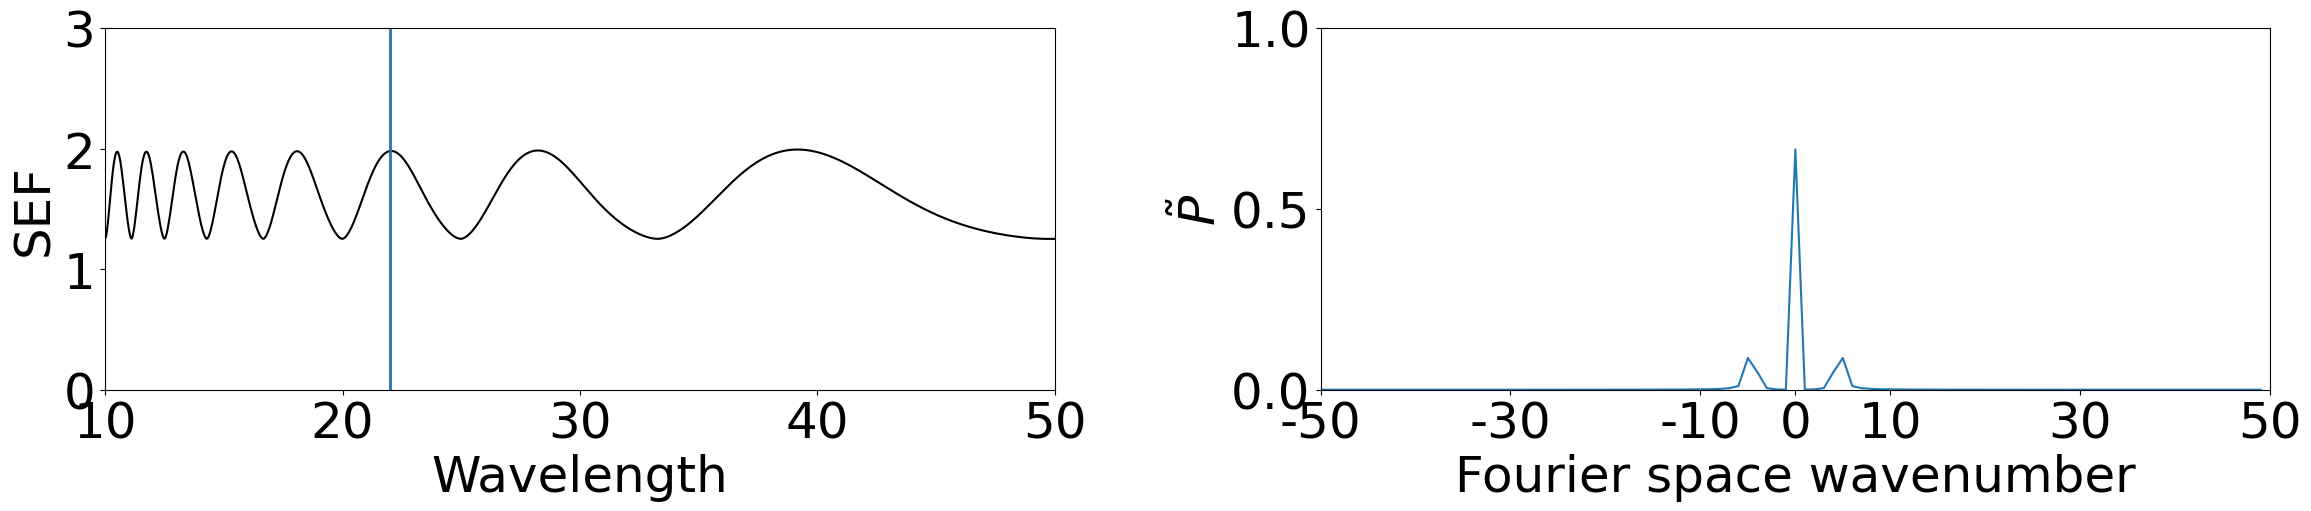

In [60]:
n = 100
wavelength = 22
amplitude = 1

# Create coordinate grid
x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelength)

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 2,
    figsize=(24, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,]}
)

fig.subplots_adjust(wspace=0.05)
# Remove ticks

# [0]
pattern_disp = pattern / np.sum(pattern)
fft_vals = np.fft.fft2(pattern)
fft_shifted = np.fft.fftshift(fft_vals)
power_spectrum = abs(fft_shifted)**2
power_spectrum_norm = power_spectrum/np.sum(power_spectrum)
power_spectrum_norm_disp = power_spectrum_norm


wav = np.linspace(10,50,1000)

sef_storage = []
for wavelen in wav:
    pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[0].plot(wav,sef_storage,"black")
axs[0].set_xlabel("Wavelength")
axs[0].set_ylabel("SEF")
axs[0].set_xlim(10,50)
axs[0].set_ylim(0,3)
axs[0].axvline(22,linewidth = 2)

#[1]

axs[1].plot(power_spectrum_norm_disp[50])
axs[1].set_xlabel("Fourier space wavenumber")
axs[1].set_ylabel(r"$\tilde{P}$")
axs[1].set_xlim(0,100)
axs[1].set_xticks([0,20,40,50,60,80,100],[-50,-30,-10,0,10,30,50])
axs[1].set_ylim(0,1)
    

plt.tight_layout()
plt.savefig('supp_fig_oscsef_2')
plt.show()

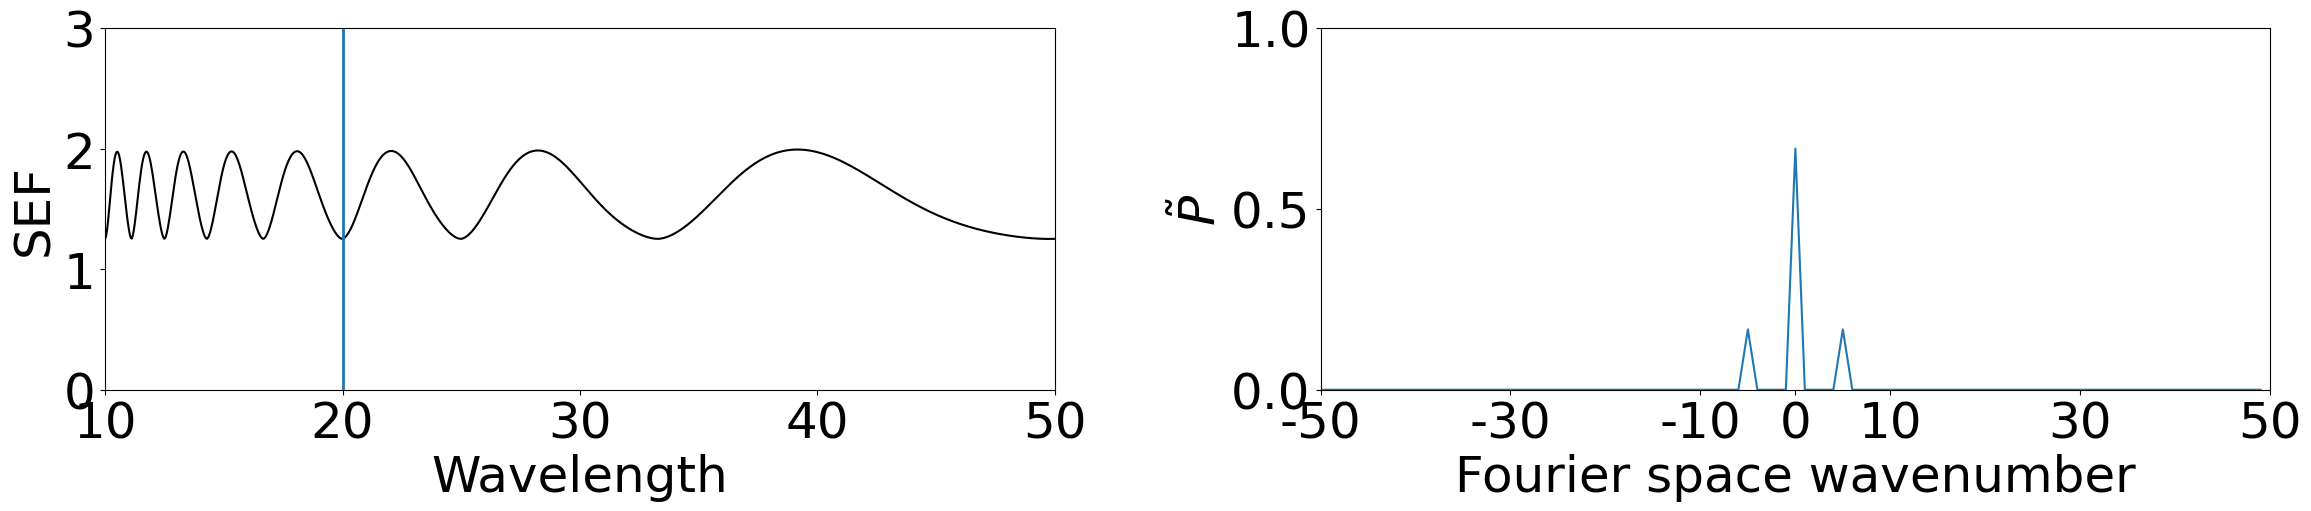

In [62]:
n = 100
wavelength = 20
amplitude = 1

# Create coordinate grid
x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelength)

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 2,
    figsize=(24, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,]}
)

fig.subplots_adjust(wspace=0.05)
# Remove ticks

# [0]
pattern_disp = pattern / np.sum(pattern)
fft_vals = np.fft.fft2(pattern)
fft_shifted = np.fft.fftshift(fft_vals)
power_spectrum = abs(fft_shifted)**2
power_spectrum_norm = power_spectrum/np.sum(power_spectrum)
power_spectrum_norm_disp = power_spectrum_norm


wav = np.linspace(10,50,1000)

sef_storage = []
for wavelen in wav:
    pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[0].plot(wav,sef_storage,"black")
axs[0].set_xlabel("Wavelength")
axs[0].set_ylabel("SEF")
axs[0].set_xlim(10,50)
axs[0].set_ylim(0,3)
axs[0].axvline(20,linewidth = 2)

#[1]

axs[1].plot(power_spectrum_norm_disp[50])
axs[1].set_xlabel("Fourier space wavenumber")
axs[1].set_ylabel(r"$\tilde{P}$")
axs[1].set_xlim(0,100)
axs[1].set_xticks([0,20,40,50,60,80,100],[-50,-30,-10,0,10,30,50])
axs[1].set_ylim(0,1)
    

plt.tight_layout()
plt.savefig('supp_fig_oscsef_3')
plt.show()

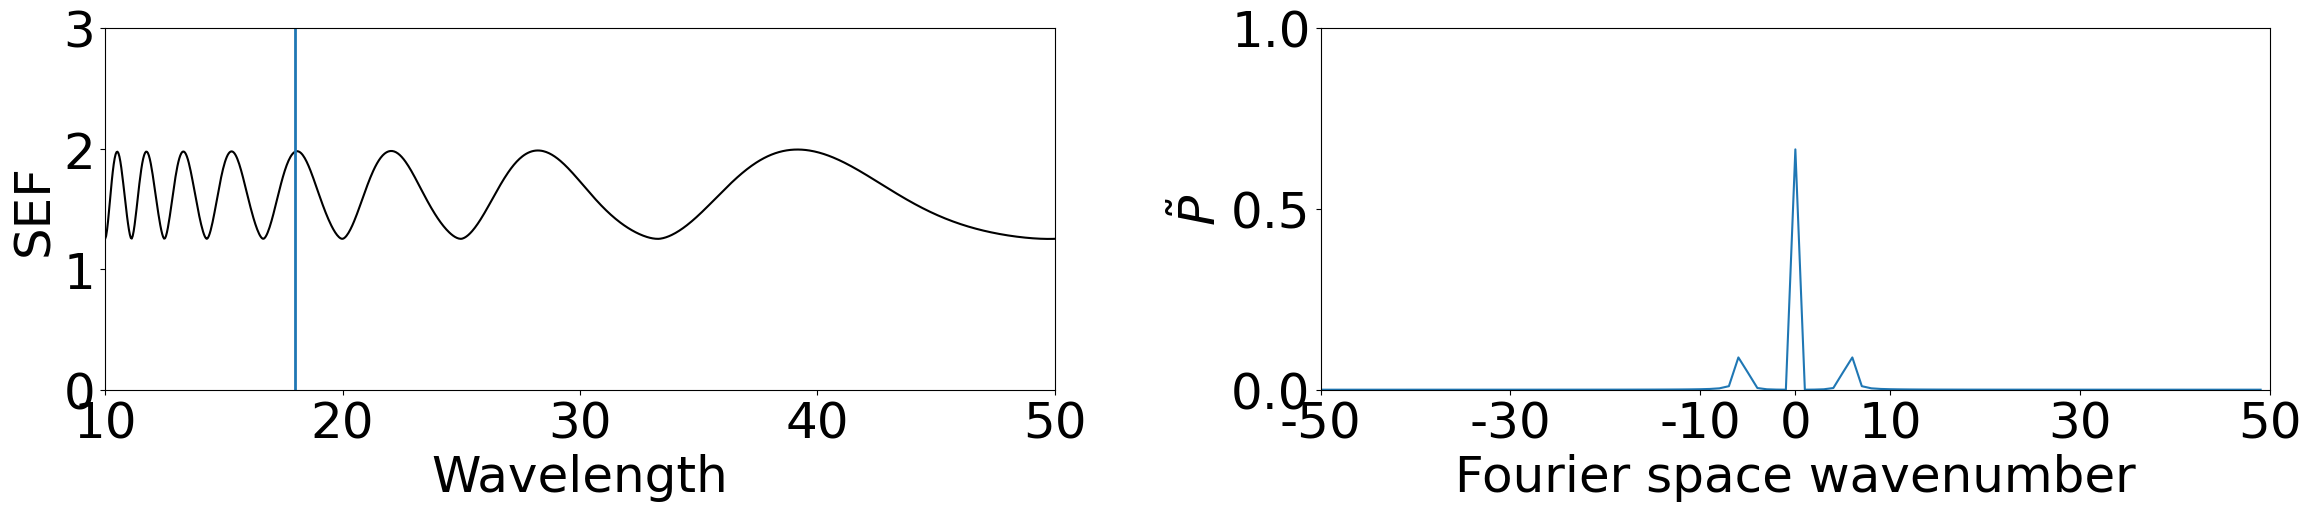

In [63]:
n = 100
wavelength = 18
amplitude = 1

# Create coordinate grid
x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelength)

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 2,
    figsize=(24, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,]}
)

fig.subplots_adjust(wspace=0.05)
# Remove ticks

# [0]
pattern_disp = pattern / np.sum(pattern)
fft_vals = np.fft.fft2(pattern)
fft_shifted = np.fft.fftshift(fft_vals)
power_spectrum = abs(fft_shifted)**2
power_spectrum_norm = power_spectrum/np.sum(power_spectrum)
power_spectrum_norm_disp = power_spectrum_norm


wav = np.linspace(10,50,1000)

sef_storage = []
for wavelen in wav:
    pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[0].plot(wav,sef_storage,"black")
axs[0].set_xlabel("Wavelength")
axs[0].set_ylabel("SEF")
axs[0].set_xlim(10,50)
axs[0].set_ylim(0,3)
axs[0].axvline(18,linewidth = 2)

#[1]

axs[1].plot(power_spectrum_norm_disp[50])
axs[1].set_xlabel("Fourier space wavenumber")
axs[1].set_ylabel(r"$\tilde{P}$")
axs[1].set_xlim(0,100)
axs[1].set_xticks([0,20,40,50,60,80,100],[-50,-30,-10,0,10,30,50])
axs[1].set_ylim(0,1)
    

plt.tight_layout()
plt.savefig('supp_fig_oscsef_4')
plt.show()

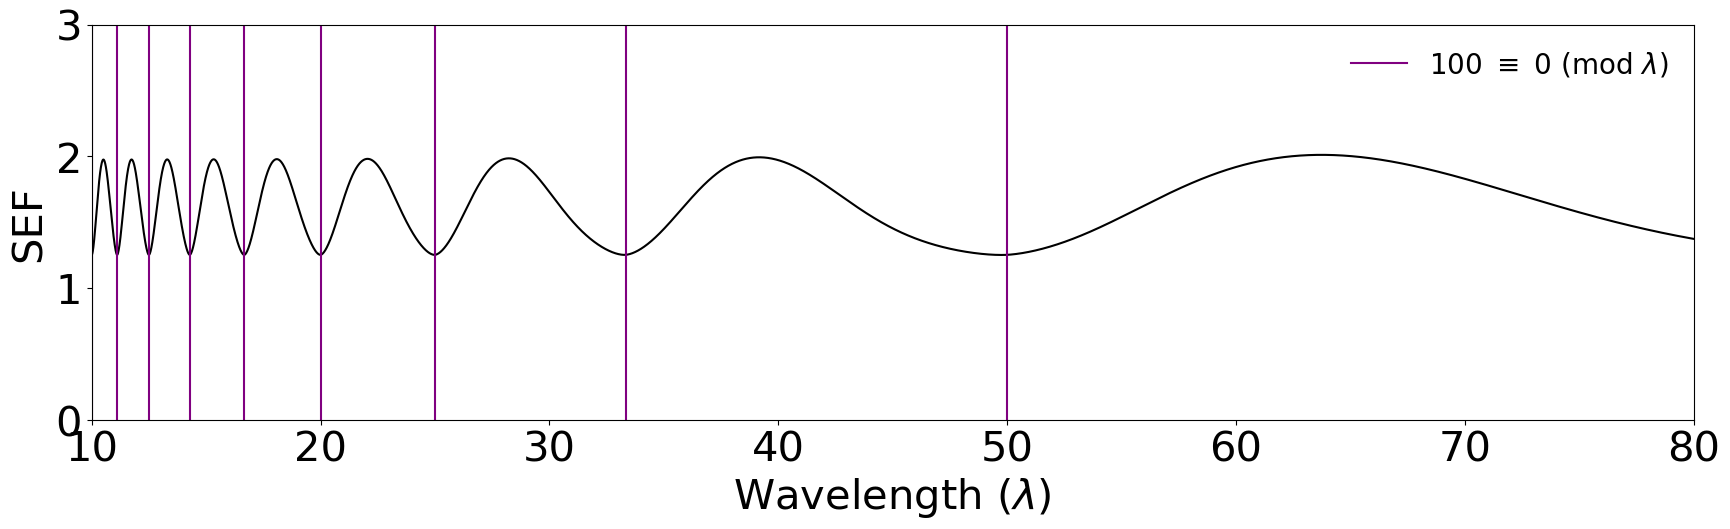

In [6]:
n = 100
wavelength = 8
amplitude = 1

# Create coordinate grid
x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelength)

fon = 30
mpl.rcParams['font.size'] = fon


# Remove ticks

# [0]
pattern_disp = pattern / np.sum(pattern)
fft_vals = np.fft.fft2(pattern)
fft_shifted = np.fft.fftshift(fft_vals)
power_spectrum = abs(fft_shifted)**2
power_spectrum_norm = power_spectrum/np.sum(power_spectrum)
power_spectrum_norm_disp = power_spectrum_norm




sef_storage = []
wav = np.linspace(10,80,10001)
for wavelen in wav:
    pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
plt.figure(figsize = (18,6))
plt.plot(wav,sef_storage, color = 'black')
plt.xlabel(r"Wavelength ($\lambda$)")
plt.ylabel("SEF")
plt.xlim(10,80)
plt.ylim(0,3)
for i in range(1,1000):
    plt.axvline(100/i, color = 'purple')
legend_line = Line2D([0], [0], color='purple')
plt.legend([legend_line], [r'100 $\equiv$ 0 (mod $\lambda$)'],fontsize = 20,frameon = False)


#[1]


plt.tight_layout()
plt.savefig('supp_fig_oscsef_gen')
plt.show()

In [34]:
wav

array([0.00000000e+00, 1.00010001e-02, 2.00020002e-02, ...,
       9.99799980e+01, 9.99899990e+01, 1.00000000e+02])